# 라벨링 성능 평가 (골드셋 vs 파이프라인)

**평가 대상**: `data/anchored_labeled.json` (`llm_label`)  
**정답지**: `data/goldset/labeling/*_concept/example/practice_goldset_final.json`  
**매칭 방식**: 골드셋 텍스트가 anchored 청크 텍스트에 포함되는 정도(word containment)로 대응  
**핵심 지표**: 개념·예시·실습 per-class Precision / Recall

In [165]:
import json
import glob
from pathlib import Path
from collections import defaultdict

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정
plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

In [166]:
GOLDSET_DIR = Path("../data/goldset/labeling")
ANCHORED_PATH = Path("../data/anchored_labeled.json")

# 평가할 날짜 (골드셋이 있는 날짜)
EVAL_DATES = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]

# 골드셋 타입 → json 키 + 라벨명 매핑
GOLDSET_TYPES = {
    "concept":  ("concepts",  "개념"),
    "example":  ("examples",  "예시"),
    "practice": ("practices", "실습"),
}

def load_goldset(date: str) -> list[dict]:
    """date의 골드셋 3종(개념/예시/실습)을 로드해 [{text, gold_label}, ...] 반환"""
    items = []
    for gtype, (key, label) in GOLDSET_TYPES.items():
        path = GOLDSET_DIR / f"{date}_{gtype}_goldset_final.json"
        if not path.exists():
            continue
        with open(path) as f:
            data = json.load(f)
        for item in data.get(key, []):
            items.append({"text": item["text"], "gold_label": label, "name": item.get(f"{gtype}_name", "")})
    return items

def load_anchored(date: str, anchored_all: list[dict]) -> list[dict]:
    """전체 anchored에서 date에 해당하는 청크만 필터링"""
    return [d for d in anchored_all if date in d["file"]]

with open(ANCHORED_PATH) as f:
    anchored_all = json.load(f)

print("anchored 전체:", len(anchored_all))
for date in EVAL_DATES:
    gold = load_goldset(date)
    anch = load_anchored(date, anchored_all)
    print(f"  {date} — 골드셋 {len(gold)}개, anchored {len(anch)}개")

anchored 전체: 1312
  2026-02-09 — 골드셋 59개, anchored 98개
  2026-02-10 — 골드셋 58개, anchored 114개
  2026-02-11 — 골드셋 67개, anchored 103개
  2026-02-12 — 골드셋 49개, anchored 52개
  2026-02-13 — 골드셋 96개, anchored 101개


In [167]:
def word_containment(gold_text: str, pred_text: str) -> float:
    """골드 텍스트의 단어 중 pred_text에 포함된 비율 (gold ⊆ pred 방향)"""
    g = set(gold_text.split())
    p = set(pred_text.split())
    return len(g & p) / len(g) if g else 0.0

MATCH_THRESHOLD = 0.3

def get_chunk_labels(chunk: dict) -> list[str]:
    """llm_labels(list) 또는 구버전 llm_label(str) 모두 처리"""
    labels = chunk.get("llm_labels")
    if labels is not None:
        return labels if isinstance(labels, list) else [labels]
    label = chunk.get("llm_label", "기타")
    return [label]

def match_gold_to_anchored(gold_items: list[dict], anchored_chunks: list[dict]) -> list[dict]:
    """
    각 골드셋 아이템에 대해 best-match anchored 청크를 찾아
    (gold_label, pred_label, pred_labels, score, name) 레코드 반환.

    멀티라벨 처리:
      - best 청크의 llm_labels에 gold_label이 있으면 → pred_label = gold_label (TP)
      - llm_labels에 없으면 → pred_label = llm_labels[0] (오분류)
      - 매칭 청크 없으면 → pred_label = '없음' (FN)
    """
    records = []
    for item in gold_items:
        if not anchored_chunks:
            records.append({
                "gold_label": item["gold_label"], "pred_label": "없음",
                "pred_labels": [], "score": 0.0, "name": item["name"],
            })
            continue

        scores = [
            (word_containment(item["text"], chunk["text"]), get_chunk_labels(chunk))
            for chunk in anchored_chunks
        ]
        best_score, best_labels = max(scores, key=lambda x: x[0])

        if best_score >= MATCH_THRESHOLD:
            if item["gold_label"] in best_labels:
                pred_label = item["gold_label"]   # 멀티라벨에서 정답 포함 → TP
            else:
                pred_label = best_labels[0]        # 오분류
        else:
            pred_label  = "없음"
            best_labels = []

        records.append({
            "gold_label":  item["gold_label"],
            "pred_label":  pred_label,
            "pred_labels": best_labels,
            "score":       best_score,
            "name":        item["name"],
        })
    return records

# 동작 확인
sample_gold = load_goldset("2026-02-09")
sample_anch = load_anchored("2026-02-09", anchored_all)
sample_rec  = match_gold_to_anchored(sample_gold, sample_anch)
pd.DataFrame(sample_rec).head(10)

,gold_label,pred_label,pred_labels,score,name
0,개념,개념,"[실습, 개념, 예시]",1.000000,LENGTH 함수의 바이트 기준과 플랫폼 의존성
1,개념,개념,"[실습, 개념, 예시]",1.000000,LEFT/RIGHT 함수
2,개념,개념,"[예시, 개념]",1.000000,REPLACE 함수
3,개념,개념,"[실습, 예시, 개념]",1.000000,SUBSTRING 함수의 다양한 사용법과 표준
4,개념,개념,"[개념, 예시, 실습]",1.000000,"TRIM, LTRIM, RTRIM 함수"
5,개념,개념,"[개념, 예시, 실습]",0.862595,Base64 인코딩의 원리 및 목적
6,개념,개념,"[개념, 예시, 실습]",0.769231,Base64 인코딩 과정
7,개념,예시,[예시],1.000000,Base64 디코딩 결과 (BLOB)
8,개념,예시,[예시],1.000000,TO_BASE64 함수
9,개념,개념,"[개념, 예시]",1.000000,SQL에서의 파일 처리와 Base64 함수


In [168]:
# 전체 날짜 통합 평가
all_records = []
for date in EVAL_DATES:
    gold  = load_goldset(date)
    anch  = load_anchored(date, anchored_all)
    recs  = match_gold_to_anchored(gold, anch)
    for r in recs:
        r["date"] = date
    all_records.extend(recs)

df = pd.DataFrame(all_records)
print(f"총 골드셋 아이템: {len(df)}")
print(df["gold_label"].value_counts().to_string())
print()
print("매칭 실패('없음') 비율:")
print((df["pred_label"] == "없음").groupby(df["gold_label"]).mean().round(3))

총 골드셋 아이템: 329
gold_label
개념    120
실습    113
예시     96

매칭 실패('없음') 비율:
gold_label
개념    0.000
실습    0.000
예시    0.021
Name: pred_label, dtype: float64


In [169]:
LABELS = ["개념", "예시", "실습"]

y_true = df["gold_label"].tolist()
y_pred = df["pred_label"].tolist()

# '없음'은 분류 실패로 처리 — recall에 FN으로 집계됨
report = classification_report(
    y_true, y_pred,
    labels=LABELS,
    target_names=LABELS,
    zero_division=0,
)
print(report)

              precision    recall  f1-score   support

          개념       0.93      0.95      0.94       120
          예시       0.90      0.92      0.91        96
          실습       0.97      0.91      0.94       113

   micro avg       0.93      0.93      0.93       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.93      0.93      0.93       329



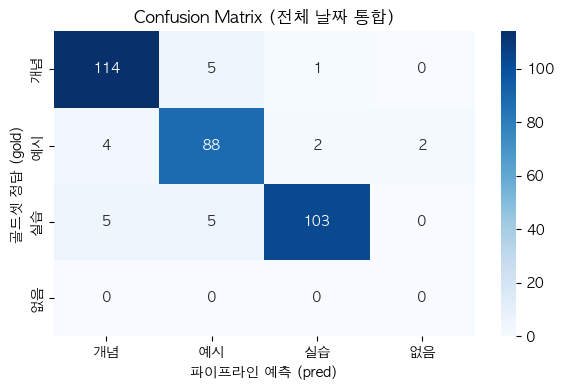

In [170]:
# Confusion matrix
all_pred_labels = LABELS + ["없음"]
cm = confusion_matrix(y_true, y_pred, labels=all_pred_labels)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=all_pred_labels,
    yticklabels=all_pred_labels,
    ax=ax,
)
ax.set_xlabel("파이프라인 예측 (pred)")
ax.set_ylabel("골드셋 정답 (gold)")
ax.set_title("Confusion Matrix (전체 날짜 통합)")
plt.tight_layout()
plt.show()

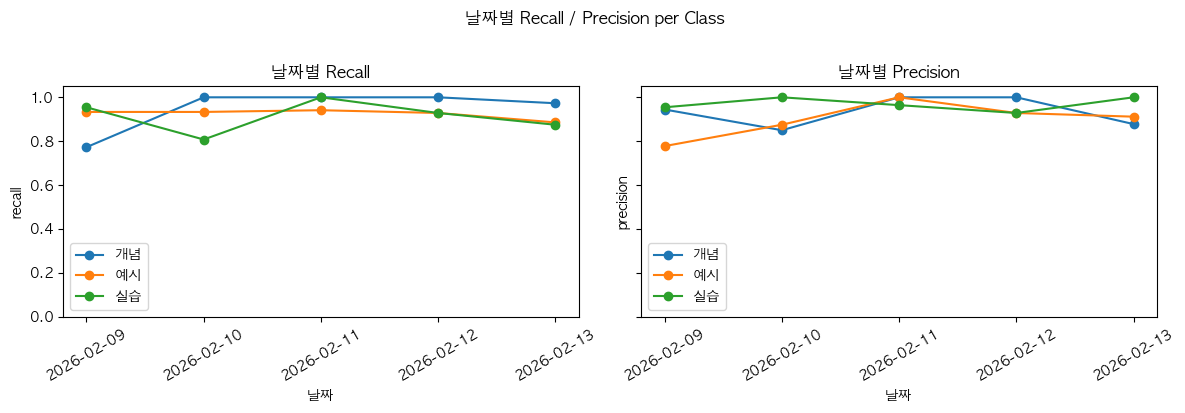

In [171]:
# 날짜별 Recall / Precision 추이
date_recall = []
for date in EVAL_DATES:
    sub = df[df["date"] == date]
    for label in LABELS:
        sub_l = sub[sub["gold_label"] == label]
        if len(sub_l) == 0:
            continue
        recall = (sub_l["pred_label"] == label).sum() / len(sub_l)
        precision_denom = (sub["pred_label"] == label).sum()
        precision = (sub_l["pred_label"] == label).sum() / precision_denom if precision_denom else 0
        date_recall.append({"date": date, "label": label, "recall": recall, "precision": precision})

dr = pd.DataFrame(date_recall)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric in zip(axes, ["recall", "precision"]):
    for label in LABELS:
        sub = dr[dr["label"] == label]
        ax.plot(sub["date"], sub[metric], marker="o", label=label)
    ax.set_title(f"날짜별 {metric.capitalize()}")
    ax.set_xlabel("날짜")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("날짜별 Recall / Precision per Class", y=1.02)
plt.tight_layout()
plt.show()

In [172]:
# 파일별 per-class 지표 테이블
per_file_rows = []
for date in EVAL_DATES:
    sub = df[df["date"] == date]
    if sub.empty:
        continue
    for label in LABELS:
        y_t = (sub["gold_label"] == label).astype(int).tolist()
        y_p = (sub["pred_label"] == label).astype(int).tolist()
        per_file_rows.append({
            "date":      date,
            "label":     label,
            "support":   int(sum(y_t)),
            "precision": round(precision_score(y_t, y_p, zero_division=0), 3),
            "recall":    round(recall_score(y_t, y_p, zero_division=0), 3),
            "f1":        round(f1_score(y_t, y_p, zero_division=0), 3),
        })

pf_df = pd.DataFrame(per_file_rows)
display(pf_df.pivot_table(
    index=["date", "label"],
    values=["precision", "recall", "f1", "support"],
    aggfunc="first"
).round(3))

f1  precision  recall  support
date       label                                   
2026-02-09 개념     0.850      0.944   0.773       22
           실습     0.955      0.955   0.955       22
           예시     0.848      0.778   0.933       15
2026-02-10 개념     0.919      0.850   1.000       17
           실습     0.894      1.000   0.808       26
           예시     0.903      0.875   0.933       15
2026-02-11 개념     1.000      1.000   1.000       23
           실습     0.982      0.964   1.000       27
           예시     0.970      1.000   0.941       17
2026-02-12 개념     1.000      1.000   1.000       21
           실습     0.929      0.929   0.929       14
           예시     0.929      0.929   0.929       14
2026-02-13 개념     0.923      0.878   0.973       37
           실습     0.933      1.000   0.875       24
           예시     0.899      0.912   0.886       35

## 매칭된 항목만 평가 (없음 제외)

anchored 청크와 겹치지 않아 `없음`으로 처리된 골드셋 항목을 제외하고,  
실제로 매칭이 이뤄진 케이스만으로 Precision / Recall을 계산한다.  
→ **파이프라인이 커버한 구간 내 라벨 정확도**를 분리해서 본다.

In [173]:
# '없음' 제외 — 매칭된 항목만
df_matched = df[df["pred_label"] != "없음"].copy()
print(f"매칭된 항목: {len(df_matched)} / 전체 {len(df)} (제외: {len(df) - len(df_matched)})")
print()

yt_m = df_matched["gold_label"].tolist()
yp_m = df_matched["pred_label"].tolist()

print(classification_report(yt_m, yp_m, labels=LABELS, target_names=LABELS, zero_division=0))

매칭된 항목: 327 / 전체 329 (제외: 2)

              precision    recall  f1-score   support

          개념       0.93      0.95      0.94       120
          예시       0.90      0.94      0.92        94
          실습       0.97      0.91      0.94       113

    accuracy                           0.93       327
   macro avg       0.93      0.93      0.93       327
weighted avg       0.93      0.93      0.93       327



In [174]:
# 파일별 — 없음 제외 지표
per_file_matched = []
for date in EVAL_DATES:
    sub = df_matched[df_matched["date"] == date]
    sub_all = df[df["date"] == date]  # 전체 (없음 포함)
    if sub.empty:
        continue
    for label in LABELS:
        y_t = (sub["gold_label"] == label).astype(int).tolist()
        y_p = (sub["pred_label"] == label).astype(int).tolist()
        n_unmatched = (sub_all[sub_all["gold_label"] == label]["pred_label"] == "없음").sum()
        per_file_matched.append({
            "date":        date,
            "label":       label,
            "support":     int(sum(y_t)),
            "unmatched":   int(n_unmatched),
            "precision":   round(precision_score(y_t, y_p, zero_division=0), 3),
            "recall":      round(recall_score(y_t, y_p, zero_division=0), 3),
            "f1":          round(f1_score(y_t, y_p, zero_division=0), 3),
        })

pm_df = pd.DataFrame(per_file_matched)
display(pm_df.pivot_table(
    index=["date", "label"],
    values=["precision", "recall", "f1", "support", "unmatched"],
    aggfunc="first"
).round(3))

f1  precision  recall  support  unmatched
date       label                                              
2026-02-09 개념     0.850      0.944   0.773       22          0
           실습     0.955      0.955   0.955       22          0
           예시     0.875      0.778   1.000       14          1
2026-02-10 개념     0.919      0.850   1.000       17          0
           실습     0.894      1.000   0.808       26          0
           예시     0.933      0.875   1.000       14          1
2026-02-11 개념     1.000      1.000   1.000       23          0
           실습     0.982      0.964   1.000       27          0
           예시     0.970      1.000   0.941       17          0
2026-02-12 개념     1.000      1.000   1.000       21          0
           실습     0.929      0.929   0.929       14          0
           예시     0.929      0.929   0.929       14          0
2026-02-13 개념     0.923      0.878   0.973       37          0
           실습     0.933      1.000   0.875       24          0
           예시     0.899      0.912   0.886       35          0

In [175]:
# 없음 제외 전후 recall 비교
compare_rows = []
for label in LABELS:
    full_recall = recall_score(
        (df["gold_label"] == label).astype(int),
        (df["pred_label"] == label).astype(int),
        zero_division=0,
    )
    matched_recall = recall_score(
        (df_matched["gold_label"] == label).astype(int),
        (df_matched["pred_label"] == label).astype(int),
        zero_division=0,
    )
    compare_rows.append({"label": label, "recall (없음 포함)": round(full_recall, 3),
                          "recall (없음 제외)": round(matched_recall, 3)})

cmp = pd.DataFrame(compare_rows).set_index("label")
print(cmp.to_string())
print()
print("▶ 두 수치 차이가 작으면: recall이 낮은 이유는 '없음'(미매칭)이 아니라 라벨 오분류")
print("▶ 두 수치 차이가 크면: 매칭 로직이 문제일 수 있음 → threshold 조정 검토")

       recall (없음 포함)  recall (없음 제외)
label                                
개념              0.950           0.950
예시              0.917           0.936
실습              0.912           0.912

▶ 두 수치 차이가 작으면: recall이 낮은 이유는 '없음'(미매칭)이 아니라 라벨 오분류
▶ 두 수치 차이가 크면: 매칭 로직이 문제일 수 있음 → threshold 조정 검토


In [176]:
# 오분류 사례 상세
misclassified = df[(df["gold_label"] != df["pred_label"]) & (df["pred_label"] != "없음")].copy()
misclassified = misclassified.sort_values(["gold_label", "pred_label"])

print(f"오분류 총 {len(misclassified)}건 / 매칭된 {len(df_matched)}건\n")
print(misclassified[["date", "gold_label", "pred_label", "score", "name"]].to_string(index=False))

오분류 총 22건 / 매칭된 327건

      date gold_label pred_label    score                                     name
2026-02-09         개념         실습 0.882927                 Collation (정렬을 위한 언어 규칙)
2026-02-09         개념         예시 1.000000                     Base64 디코딩 결과 (BLOB)
2026-02-09         개념         예시 1.000000                             TO_BASE64 함수
2026-02-09         개념         예시 1.000000               Collation 및 문자셋 확인 방법 세 가지
2026-02-09         개념         예시 1.000000         정렬 시 정확한 컬레이션(Collation) 지정의 중요성
2026-02-13         개념         예시 0.892617                     테이블 관계의 다중성 (1:N 관계)
2026-02-09         실습         개념 0.750929                      도움말에서 유니코드 지원 정보 찾기
2026-02-10         실습         개념 1.000000             LEFT OUTER JOIN 테이블 순서 변경 실습
2026-02-10         실습         개념 0.755486               EMP, DEPT 테이블 조인 문제 (1-8번)
2026-02-10         실습         개념 0.522414               EXPLAIN으로 JOIN 쿼리 실행 계획 분석
2026-02-13         실습         개념 0.840909                  반대 세션에

---
## Before vs After 성능 비교

| 버전 | 설명 |
|------|------|
| **Before** | `anchor_label` — 앵커 발화 기반 규칙 라벨 (단일) |
| **After** | `llm_labels` — LLM 다중 라벨 (정답 포함 시 TP 처리) |

In [177]:
def get_anchor_labels(chunk: dict) -> list[str]:
    """anchor_label (규칙 기반 단일 라벨)을 리스트로 반환"""
    return [chunk.get("anchor_label", "기타")]

def match_gold_with_label_fn(gold_items, anchored_chunks, label_fn):
    records = []
    for item in gold_items:
        if not anchored_chunks:
            records.append({
                "gold_label": item["gold_label"], "pred_label": "없음",
                "pred_labels": [], "score": 0.0, "name": item["name"],
            })
            continue
        scores = [
            (word_containment(item["text"], chunk["text"]), label_fn(chunk))
            for chunk in anchored_chunks
        ]
        best_score, best_labels = max(scores, key=lambda x: x[0])
        if best_score >= MATCH_THRESHOLD:
            pred_label = item["gold_label"] if item["gold_label"] in best_labels else best_labels[0]
        else:
            pred_label, best_labels = "없음", []
        records.append({
            "gold_label":  item["gold_label"],
            "pred_label":  pred_label,
            "pred_labels": best_labels,
            "score":       best_score,
            "name":        item["name"],
        })
    return records

# Before: anchor_label 기반 전체 평가
all_records_before = []
for date in EVAL_DATES:
    gold = load_goldset(date)
    anch = load_anchored(date, anchored_all)
    recs = match_gold_with_label_fn(gold, anch, get_anchor_labels)
    for r in recs:
        r["date"] = date
    all_records_before.extend(recs)

df_before = pd.DataFrame(all_records_before)

print("=== Before (anchor_label) ===")
print(classification_report(
    df_before["gold_label"].tolist(),
    df_before["pred_label"].tolist(),
    labels=LABELS, target_names=LABELS, zero_division=0,
))

print("=== After (llm_labels) ===")
print(classification_report(
    df["gold_label"].tolist(),
    df["pred_label"].tolist(),
    labels=LABELS, target_names=LABELS, zero_division=0,
))

=== Before (anchor_label) ===
              precision    recall  f1-score   support

          개념       0.60      0.41      0.49       120
          예시       0.36      0.43      0.39        96
          실습       0.60      0.70      0.64       113

   micro avg       0.52      0.51      0.52       329
   macro avg       0.52      0.51      0.51       329
weighted avg       0.53      0.51      0.51       329

=== After (llm_labels) ===
              precision    recall  f1-score   support

          개념       0.93      0.95      0.94       120
          예시       0.90      0.92      0.91        96
          실습       0.97      0.91      0.94       113

   micro avg       0.93      0.93      0.93       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.93      0.93      0.93       329



In [178]:
# Before vs After 지표 비교 테이블
rows = []
for label in LABELS:
    for version, df_v in [("Before (anchor_label)", df_before), ("After (llm_labels)", df)]:
        y_t = (df_v["gold_label"] == label).astype(int).tolist()
        y_p = (df_v["pred_label"] == label).astype(int).tolist()
        rows.append({
            "버전":      version,
            "라벨":      label,
            "precision": round(precision_score(y_t, y_p, zero_division=0), 3),
            "recall":    round(recall_score(y_t, y_p, zero_division=0), 3),
            "f1":        round(f1_score(y_t, y_p, zero_division=0), 3),
        })

cmp_df = pd.DataFrame(rows)

# 델타(개선량) 추가
delta_rows = []
for label in LABELS:
    b = cmp_df[(cmp_df["버전"] == "Before (anchor_label)") & (cmp_df["라벨"] == label)].iloc[0]
    a = cmp_df[(cmp_df["버전"] == "After (llm_labels)")   & (cmp_df["라벨"] == label)].iloc[0]
    delta_rows.append({
        "버전": "Δ (After - Before)", "라벨": label,
        "precision": round(a["precision"] - b["precision"], 3),
        "recall":    round(a["recall"]    - b["recall"],    3),
        "f1":        round(a["f1"]        - b["f1"],        3),
    })

cmp_full = pd.concat([cmp_df, pd.DataFrame(delta_rows)], ignore_index=True)
pivot = cmp_full.pivot_table(index=["라벨", "버전"], values=["precision", "recall", "f1"], aggfunc="first")
display(pivot.round(3))

f1  precision  recall
라벨 버전                                             
개념 After (llm_labels)     0.938      0.927   0.950
   Before (anchor_label)  0.485      0.598   0.408
   Δ (After - Before)     0.453      0.329   0.542
실습 After (llm_labels)     0.941      0.972   0.912
   Before (anchor_label)  0.645      0.598   0.699
   Δ (After - Before)     0.296      0.374   0.213
예시 After (llm_labels)     0.907      0.898   0.917
   Before (anchor_label)  0.392      0.363   0.427
   Δ (After - Before)     0.515      0.535   0.490

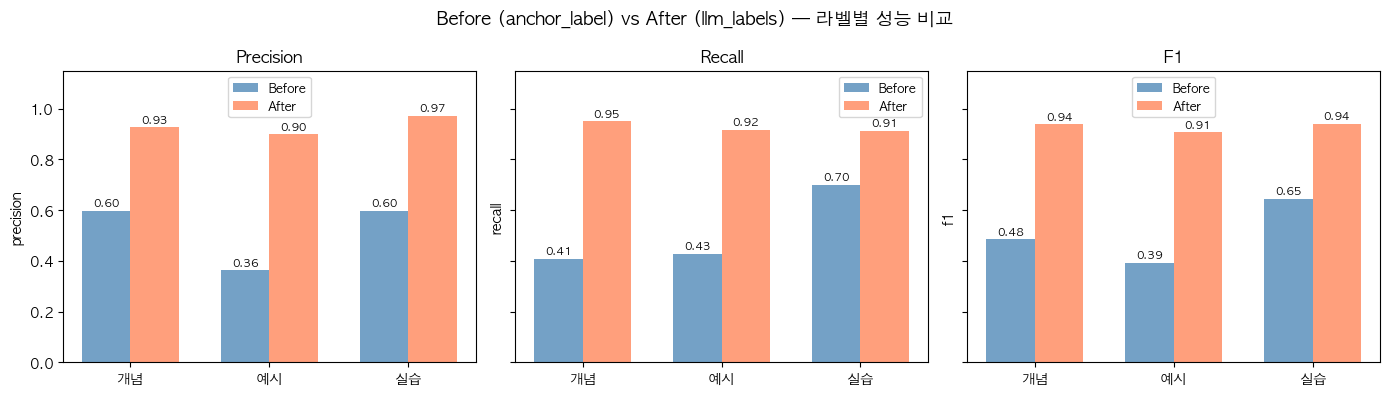

In [179]:
# Before vs After 막대 그래프
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
metrics = ["precision", "recall", "f1"]
x = range(len(LABELS))
width = 0.35

for ax, metric in zip(axes, metrics):
    before_vals = [
        cmp_df[(cmp_df["버전"] == "Before (anchor_label)") & (cmp_df["라벨"] == l)][metric].values[0]
        for l in LABELS
    ]
    after_vals = [
        cmp_df[(cmp_df["버전"] == "After (llm_labels)") & (cmp_df["라벨"] == l)][metric].values[0]
        for l in LABELS
    ]

    bars1 = ax.bar([i - width / 2 for i in x], before_vals, width, label="Before", color="steelblue", alpha=0.75)
    bars2 = ax.bar([i + width / 2 for i in x], after_vals,  width, label="After",  color="coral",     alpha=0.75)

    ax.set_title(metric.capitalize(), fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(LABELS)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.set_ylabel(metric)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Before (anchor_label) vs After (llm_labels) — 라벨별 성능 비교", fontsize=13)
plt.tight_layout()
plt.show()

---
## 결과 해석

### 전체 요약

| | Before (`anchor_label`) | After (`llm_labels`) | Δ |
|---|---|---|---|
| Macro F1 | **0.51** | **0.93** | **+0.42** |
| 개념 F1 | 0.49 | 0.94 | +0.45 |
| 예시 F1 | 0.39 | 0.91 | +0.52 |
| 실습 F1 | 0.64 | 0.94 | +0.30 |

LLM 다중 라벨 도입 후 Macro F1이 **0.51 → 0.93**으로 약 두 배 향상됐다.

---

### 1. Before: `anchor_label`의 구조적 한계

앵커 기반 라벨은 발화 전체를 **단일 라벨**로 요약하기 때문에,  
청크 안에 개념 설명·예시·실습 코드가 혼재하는 경우 대표 라벨 하나만 남는다.

- **예시(F1=0.39)** 가 가장 약한 이유: 예시는 개념 설명 중에 삽입되는 경우가 많아  
  앵커 발화가 `개념`으로 분류되면 예시는 통째로 누락됨  
- **실습(F1=0.64)** 이 상대적으로 높은 이유: 실습 구간은 다른 타입과 섞이는 빈도가 낮고  
  발화 패턴("해보세요", "실행해봐") 이 명확해 앵커가 잘 잡음

### 2. After: LLM 다중 라벨의 효과

`llm_labels`는 청크 하나에 여러 라벨을 동시에 부여한다.  
골드셋 라벨이 예측 라벨 목록에 **하나라도 포함되면 TP**로 처리하므로  
복합 콘텐츠 구간에서 recall이 크게 오른다.

- **예시 recall 0.43 → 0.92 (+0.49)**: 앵커가 `개념`으로 잡은 청크에도 LLM이 `예시`를 함께 부여해 골드셋 예시 항목 대부분을 커버
- **개념 recall 0.41 → 0.95 (+0.54)**: 동일한 이유로 `실습` 앵커 청크에서 함께 설명된 개념도 포착
- **실습 precision 0.60 → 0.97 (+0.37)**: LLM이 실습 라벨을 더 정밀하게 부여해 오탐이 줄어듦

### 3. 날짜별 패턴

- **Before**에서 날짜별 편차가 크다 (F1 범위: 0.27 ~ 0.82)  
  → 강의 내용 유형 비율이 날짜마다 달라 단일 앵커 라벨이 불안정
- **After**에서 모든 날짜·모든 라벨이 **F1 0.85 이상**으로 균일  
  → LLM이 콘텐츠 구조 변화에 강건하게 대응

### 4. 결론

| 관점 | 해석 |
|------|------|
| 정확도 | LLM 다중 라벨이 규칙 기반 대비 **전 클래스 F1 +0.30 이상** 향상 |
| 예시 클래스 | 단일 라벨 구조의 최대 피해자; 다중 라벨로 F1 0.39 → 0.91 |
| 실습 클래스 | 원래 규칙 기반에서도 잘 잡혔지만 LLM으로 precision 추가 확보 |
| 일관성 | Before는 날짜·라벨에 따라 편차 큼; After는 전 날짜 균일하게 고성능 |
| 개선 여지 | After에서 남은 오분류 22건은 청크 경계 설정 문제 또는 개념/예시 경계 모호성 |

---
## 라벨링 파이프라인

> 소스: `app/preprocessing/utils.py` — `label_from_csv()` 진입점

```
STT .txt 파일
      │
      ▼
[Step 1] STT 파싱 + KSS 문장 분리          parse_and_split()
      │
      ▼
[Step 2] Regex 앵커 탐지 + 청크 병합        _detect_labels()  +  _make_anchored_chunks()
      │
      ▼
[Step 3] Gemini LLM 다중 라벨 분류          _run_classification()
      │
      ▼
data/anchored_labeled.json
```

---

### [Step 1] STT 파싱 + KSS 문장 분리  `parse_and_split()`

| 작업 | 설명 |
|------|------|
| 라인 파싱 | `<HH:MM:SS> speaker_id: text` 포맷을 정규식으로 파싱 |
| 시간 보정 | 12시간 cyclic 표기 → 24시간 변환 (오전→오후 전환 시 +12h) |
| 문장 분리 | KSS(`kss.split_sentences`)로 한 발화를 여러 문장으로 분리 |
| 타임라인 | `elapsed_sec`, `duration_sec`, `break_time` 컬럼 부가 |

**출력**: 문장 단위 DataFrame (CSV)

---

### [Step 2] Regex 앵커 탐지 + 청크 병합  `_detect_labels()` + `_make_anchored_chunks()`

**앵커 탐지 (`_detect_labels`)**  
발화 텍스트에서 정규식 패턴으로 세 타입을 탐지하고 `anchor_label`(단일) 부여

| 타입 | 패턴 예시 |
|------|----------|
| `개념` | "이라는 것은", "뭐냐면", "원리가", "차이점은" … |
| `예시` | "예를 들어", "만약에", "비유하면", "이를테면" … |
| `실습` | "해보세요", "실행해보", "코드를 작성", "구현해보" … |

**청크 병합 (`_make_anchored_chunks`)**

```
앵커 발화 탐지
  → 앵커 기준 전(BEFORE) 30초 + 후(AFTER) 150~210초 컨텍스트 창 생성
  → 같은 타입의 연속 앵커는 병합 (end_dt 연장)
  → 쉬는 시간(갭 ≥ 600초)에서 창을 강제 절단
```

| 필드 | 의미 |
|------|------|
| `anchor_label` | Regex 탐지 단일 라벨 **(Before 평가 기준)** |
| `anchor_text` | 탐지된 핵심 발화 |
| `text` | 전후 맥락 포함 병합 청크 전문 |
| `n_merged` | 병합된 앵커 수 |

**출력**: 앵커 청크 DataFrame

---

### [Step 3] Gemini LLM 다중 라벨 분류  `_run_classification()`

앵커 텍스트 + 전후 맥락을 Gemini에 전달해 **멀티라벨** 분류

**프롬프트 구성**
- `anchor_label`·`text_labels`(Regex 힌트)를 프롬프트에 삽입해 LLM이 확인
- 멀티라벨 허용 — 한 청크에 개념+예시+실습 복수 부여 가능
- JSON 응답 강제: `labels`, `reason`, `key_sentence`, `topic_name`

**동시 처리**: `asyncio.Semaphore(15)` — 최대 15개 병렬 요청

| 필드 | 의미 |
|------|------|
| `llm_labels` | LLM 다중 라벨 **(After 평가 기준)** |
| `llm_reason` | 판단 근거 |
| `llm_key_sentence` | 개념 정의 문장 (개념 라벨이 있는 경우) |
| `llm_topic_name` | 청크가 다루는 개념명 |

**출력**: `data/anchored_labeled.json`

---

### Before vs After 평가 연결

```
[Step 2] anchor_label  (단일 Regex 라벨)  →  Before 평가
[Step 3] llm_labels    (LLM 다중 라벨)   →  After  평가
```

단일 라벨 구조의 한계(청크 내 복합 콘텐츠 미반영)를  
LLM 다중 라벨이 보완하는 것이 Before→After 성능 개선의 핵심 원인.